# VMD-DTW 相似性分析

对预处理后的所有建筑负荷数据进行标准化，然后计算任意两个建筑负荷序列之间的 VMD-DTW 距离，用于选择迁移学习最佳源域-目标域组合。

## 分析流程

1. **数据标准化**：对所有建筑的特征数据进行标准化（仅在自身维度上）
2. **VMD参数优化与分解**：基于 IMF 经验熵适应度函数，联合优化 `K` 和 `alpha` 后进行 VMD 分解
3. **DTW距离**：计算各IMF的动态时间规整距离
4. **加权DTW距离**：低频IMF权重更高，计算综合距离
5. **迁移方向**：数据量大的建筑作为源域，数据量小的建筑作为目标域

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from vmdpy import VMD
from dtaidistance import dtw
from scipy.optimize import differential_evolution
from typing import Tuple, Dict
from itertools import combinations
from concurrent.futures import ThreadPoolExecutor, as_completed
from tabulate import tabulate
import json

# 从 src 模块导入共享配置
from src import (
    BASE_DIR,
    BUILDINGS_DIR,
    BUILDINGS,
    TARGET_COL,
    TIME_COL,
    TARGET_SAMPLE_START,
    TARGET_SAMPLE_END,
    TRAIN_RATIO,
    SEED,
    FIGURES_DIR,
    setup_plot_style,
)

np.random.seed(SEED)
setup_plot_style()

## 加载并标准化数据

对每个建筑的负荷数据进行标准化（仅在自身维度上），用于相似性分析。

In [2]:
def load_and_standardize_building(building_name: str) -> Tuple[pd.DataFrame, StandardScaler]:
    path = BUILDINGS_DIR / f'{building_name}_特征.csv'
    df = pd.read_csv(path, encoding='utf-8-sig')
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors='coerce')
    df = df.dropna(subset=[TIME_COL, TARGET_COL]).sort_values(TIME_COL).reset_index(drop=True)
    
    # 保存原始负荷数据
    df['original_load'] = df[TARGET_COL].copy()
    
    # 标准化负荷数据（用于VMD分析）
    scaler = StandardScaler()
    df[TARGET_COL] = scaler.fit_transform(df[[TARGET_COL]])
    
    return df, scaler

# 加载所有建筑数据
building_data = {}
for name in BUILDINGS:
    df, scaler = load_and_standardize_building(name)
    building_data[name] = {
        'df': df,
        'scaler': scaler,
    }

## VMD-DTW 分析函数

本节先定义 VMD 参数搜索范围和经验熵适应度函数。候选参数由差分进化算法在 `K ∈ [2, 6]`、`alpha ∈ [500, 5000]` 内生成，其中 `K` 是模态数，必须在适应度函数调用处四舍五入并限制到整数范围；`alpha` 是连续惩罚因子，直接按给定范围裁剪。

差分进化算法包含随机初始化和变异过程。为保证实验可复现，notebook 直接使用从 `src.config` 导入的全局 `SEED` 作为优化器随机种子。


In [3]:
VMD_K_BOUNDS = (2, 6)
VMD_ALPHA_BOUNDS = (500.0, 5000.0)
VMD_ENTROPY_BINS = 30
VMD_OPT_MAXITER = 8
VMD_OPT_POPSIZE = 5


def empirical_entropy(values: np.ndarray, bins: int = VMD_ENTROPY_BINS) -> float:
    """基于直方图经验概率密度估计 Shannon 经验熵。"""
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size == 0 or np.nanstd(values) < 1e-12:
        return 0.0

    density, bin_edges = np.histogram(values, bins=bins, density=True)
    probabilities = density * np.diff(bin_edges)
    probabilities = probabilities[np.isfinite(probabilities) & (probabilities > 0)]
    probability_sum = probabilities.sum()
    if probability_sum <= 0:
        return 0.0

    probabilities = probabilities / probability_sum
    return float(-np.sum(probabilities * np.log(probabilities)))


def compute_imf_energy_weights(imfs: np.ndarray) -> np.ndarray:
    """按 IMF 能量占比计算经验熵加权系数。"""
    energies = np.sum(np.square(imfs), axis=1)
    total_energy = energies.sum()
    if total_energy <= 0 or not np.isfinite(total_energy):
        return np.full(imfs.shape[0], 1.0 / imfs.shape[0])
    return energies / total_energy


def compute_weighted_empirical_entropy(imfs: np.ndarray) -> Tuple[float, np.ndarray, np.ndarray]:
    """计算所有 IMF 经验熵的能量加权和，作为 VMD 参数适应度。"""
    entropy_values = np.array([empirical_entropy(imf) for imf in imfs], dtype=np.float64)
    entropy_weights = compute_imf_energy_weights(imfs)
    fitness = float(np.sum(entropy_values * entropy_weights))
    return fitness, entropy_values, entropy_weights


def _evaluate_vmd_entropy(signal: np.ndarray, K: int, alpha: float) -> Dict:
    """执行一次 VMD 并返回 IMF 经验熵适应度。"""
    imfs, _, _ = VMD(signal, alpha, 0, K, 0, 1, 1e-7)
    weighted_entropy, imf_entropy, entropy_weights = compute_weighted_empirical_entropy(imfs)
    return {
        'weighted_entropy': weighted_entropy,
        'imf_entropy': imf_entropy,
        'entropy_weights': entropy_weights,
    }


def optimize_vmd_parameters_for_pair(
    name_a: str,
    name_b: str,
    signal_a: np.ndarray,
    signal_b: np.ndarray,
) -> Dict:
    """通过差分进化最小化两个建筑 IMF 经验熵均值，联合优化 K 和 alpha。"""
    history = []
    cache = {}

    def objective(params: np.ndarray) -> float:
        K = int(np.clip(np.rint(params[0]), VMD_K_BOUNDS[0], VMD_K_BOUNDS[1]))
        alpha = float(np.clip(params[1], *VMD_ALPHA_BOUNDS))
        cache_key = (K, round(alpha, 6))
        if cache_key in cache:
            return cache[cache_key]['fitness']

        try:
            entropy_a = _evaluate_vmd_entropy(signal_a, K, alpha)
            entropy_b = _evaluate_vmd_entropy(signal_b, K, alpha)
            fitness = 0.5 * (entropy_a['weighted_entropy'] + entropy_b['weighted_entropy'])
            if not np.isfinite(fitness):
                fitness = np.inf
        except Exception:
            fitness = np.inf
            entropy_a = None
            entropy_b = None

        record = {
            'K': K,
            'alpha': alpha,
            'fitness': float(fitness),
            'entropy_a': float(entropy_a['weighted_entropy']) if entropy_a is not None else np.inf,
            'entropy_b': float(entropy_b['weighted_entropy']) if entropy_b is not None else np.inf,
        }
        history.append(record)
        cache[cache_key] = record
        return float(fitness)

    opt_result = differential_evolution(
        objective,
        bounds=[VMD_K_BOUNDS, VMD_ALPHA_BOUNDS],
        seed=SEED,
        maxiter=VMD_OPT_MAXITER,
        popsize=VMD_OPT_POPSIZE,
        tol=0.01,
        atol=1e-4,
        polish=False,
        updating='immediate',
    )

    finite_history = [item for item in history if np.isfinite(item['fitness'])]
    if not finite_history:
        raise RuntimeError(f'{name_a}-{name_b} 的 VMD 参数优化未得到有效适应度')

    best_record = min(finite_history, key=lambda item: item['fitness'])
    best_K = int(best_record['K'])
    best_alpha = float(best_record['alpha'])
    final_entropy_a = _evaluate_vmd_entropy(signal_a, best_K, best_alpha)
    final_entropy_b = _evaluate_vmd_entropy(signal_b, best_K, best_alpha)
    final_fitness = 0.5 * (final_entropy_a['weighted_entropy'] + final_entropy_b['weighted_entropy'])

    return {
        'K': best_K,
        'alpha': best_alpha,
        'entropy_fitness': float(final_fitness),
        'entropy_a': float(final_entropy_a['weighted_entropy']),
        'entropy_b': float(final_entropy_b['weighted_entropy']),
        'imf_entropy_a': final_entropy_a['imf_entropy'],
        'imf_entropy_b': final_entropy_b['imf_entropy'],
        'entropy_weights_a': final_entropy_a['entropy_weights'],
        'entropy_weights_b': final_entropy_b['entropy_weights'],
        'optimization_success': bool(opt_result.success),
        'optimization_message': str(opt_result.message),
        'optimization_nit': int(opt_result.nit),
        'optimization_nfev': int(opt_result.nfev),
        'optimization_history': history,
    }


def compute_imf_weights(center_freq: np.ndarray, decay_factor: float = 2.0) -> np.ndarray:
    """
    基于中心频率计算各 IMF 层的权重
    
    Args:
        center_freq: 各 IMF 的中心频率数组（按频率从低到高排列）
        decay_factor: 衰减因子，控制权重递减速度
                     - decay_factor=1: 线性递减
                     - decay_factor=2: 平方反比（推荐）
                     - decay_factor>2: 更强调低频
    
    Returns:
        归一化的权重数组
    """
    # 避免除零
    freq_safe = np.maximum(center_freq, 1e-6)
    
    # 基于中心频率的权重：频率越低，权重越大
    # 使用幂函数衰减：weight ∝ 1 / f^decay_factor
    weights = 1.0 / (freq_safe ** (1.0 / decay_factor))
    weights = weights / weights.sum()
    
    return weights


def compute_vmd_dtw_similarity(
    signal_a: np.ndarray,
    signal_b: np.ndarray,
    K: int,
    alpha: float,
) -> Dict:
    """计算两个信号的 VMD-DTW 加权距离（对称度量）。"""
    # VMD 分解
    u_a, _, omega_a = VMD(signal_a, alpha, 0, K, 0, 1, 1e-7)
    u_b, _, omega_b = VMD(signal_b, alpha, 0, K, 0, 1, 1e-7)
    
    # 提取中心频率（取两个信号的平均值计算权重）
    center_freq_a = omega_a[-1, :K]
    center_freq_b = omega_b[-1, :K]
    center_freq_mean = (center_freq_a + center_freq_b) / 2
    
    # 基于中心频率计算权重
    weights_norm = compute_imf_weights(center_freq_mean)
    
    # 计算各层 DTW 距离
    dtw_distances = []
    for i in range(K):
        dtw_dist = dtw.distance(u_a[i, :], u_b[i, :], use_pruning=True)
        dtw_distances.append(dtw_dist)
    
    # 加权 DTW（主判据，距离越小越相似）
    weighted_dtw = np.sum(np.array(dtw_distances) * weights_norm)

    # 原始序列 DTW 距离
    dtw_original = dtw.distance(signal_a, signal_b, use_pruning=True)
    
    return {
        'K': K,
        'alpha': alpha,
        'dtw_distances': dtw_distances,
        'dtw_original': dtw_original,
        'weighted_dtw': weighted_dtw,
        'weights': weights_norm,
        'u_a': u_a,
        'u_b': u_b,
        'center_freq_a': center_freq_a,
        'center_freq_b': center_freq_b,
    }


def _compute_pair_similarity_task(args: tuple) -> Dict:
    """并行计算单个建筑对的 VMD 参数优化结果和 VMD-DTW 距离。"""
    name_a, name_b, signal_a, signal_b = args
    
    optimization = optimize_vmd_parameters_for_pair(name_a, name_b, signal_a, signal_b)
    result = compute_vmd_dtw_similarity(signal_a, signal_b, optimization['K'], optimization['alpha'])
    result.update(optimization)
    result['name_a'] = name_a
    result['name_b'] = name_b
    
    return result


## 计算所有建筑对的 VMD-DTW 距离

基于目标小样本窗口前 `TRAIN_RATIO` 部分的公共时间段，对每个建筑对联合优化 VMD 分解层数 `K` 和惩罚因子 `alpha`，再计算 VMD-DTW 距离。由于优化目标是建筑对适应度 `F_pair = (F_A + F_B) / 2`，最优参数依赖两栋建筑的组合“建筑对 → 一组 `K` 和 `alpha`”。


In [4]:
# 使用所有建筑在目标小样本窗口内的公共时间索引计算训练段边界
sample_indices = []
for item in building_data.values():
    idx = item['df'].set_index(TIME_COL).index
    mask = (idx >= TARGET_SAMPLE_START) & (idx < TARGET_SAMPLE_END)
    sample_indices.append(idx[mask])

common_sample_idx = sample_indices[0]
for idx in sample_indices[1:]:
    common_sample_idx = common_sample_idx.intersection(idx)

common_sample_idx = common_sample_idx.sort_values()
train_end = int(len(common_sample_idx) * TRAIN_RATIO)
SIMILARITY_SELECTION_START = pd.to_datetime(TARGET_SAMPLE_START)
SIMILARITY_SELECTION_END = common_sample_idx[train_end]

# 记录每个建筑的数据量，用于后续确定迁移方向
building_data_count = {}
for name in BUILDINGS:
    load_series = building_data[name]['df'].set_index(TIME_COL)[TARGET_COL].dropna()
    building_data_count[name] = len(load_series)

# 准备每对建筑的数据（距离对称只计算一次）
pair_tasks = []
pair_metadata = []

for name_a, name_b in combinations(BUILDINGS, 2):
    # 获取公共时间段
    df_a = building_data[name_a]['df']
    df_b = building_data[name_b]['df']
    
    load_a = df_a.set_index(TIME_COL)[TARGET_COL].dropna()
    load_b = df_b.set_index(TIME_COL)[TARGET_COL].dropna()
    
    common_idx = load_a.index.intersection(load_b.index)
    
    # 筛选相似性选择时间段
    mask = (common_idx >= SIMILARITY_SELECTION_START) & (common_idx < SIMILARITY_SELECTION_END)
    common_idx = common_idx[mask]
    
    # 提取标准化信号（用于VMD分析）
    signal_a = load_a.loc[common_idx].values.astype(np.float64)
    signal_b = load_b.loc[common_idx].values.astype(np.float64)
    
    # 提取原始负荷数据（用于可视化）
    original_load_a = df_a.set_index(TIME_COL).loc[common_idx, 'original_load']
    original_load_b = df_b.set_index(TIME_COL).loc[common_idx, 'original_load']
    
    pair_tasks.append((name_a, name_b, signal_a, signal_b))
    pair_metadata.append({
        'name_a': name_a,
        'name_b': name_b,
        'common_idx': common_idx,
        'original_load_a': original_load_a,
        'original_load_b': original_load_b,
    })

# 并行计算 VMD-DTW 距离
all_results = {}
max_workers = min(len(pair_tasks), 3)

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {executor.submit(_compute_pair_similarity_task, task): i 
               for i, task in enumerate(pair_tasks)}
    
    completed = 0
    for future in as_completed(futures):
        idx = futures[future]
        try:
            result = future.result()
            pair_key = f"{result['name_a']}-{result['name_b']}"
            
            meta = pair_metadata[idx]
            result['common_index'] = meta['common_idx']
            result['original_load_a'] = meta['original_load_a']
            result['original_load_b'] = meta['original_load_b']
            
            all_results[pair_key] = result
            
            completed += 1
            print(
                f"[{completed}/{len(pair_tasks)}] {result['name_a']}-{result['name_b']} "
                f"K={result['K']}, alpha={result['alpha']:.2f}, "
                f"经验熵适应度={result['entropy_fitness']:.4f}, "
                f"加权DTW={result['weighted_dtw']:.4f}"
            )
            
        except Exception as e:
            print(f"  任务失败: {e}")

# 根据数据量确定每对的迁移方向（数据量大的 → 源域）
for pair_key, result in all_results.items():
    name_a, name_b = result['name_a'], result['name_b']
    if building_data_count[name_a] >= building_data_count[name_b]:
        result['source'] = name_a
        result['target'] = name_b
    else:
        result['source'] = name_b
        result['target'] = name_a


[1/10] 南阶-西阶 K=4, alpha=4861.48, 经验熵适应度=2.8861, 加权DTW=5.2471
[2/10] 南阶-环工 K=3, alpha=927.82, 经验熵适应度=3.0763, 加权DTW=3.1839
[3/10] 南阶-土木 K=4, alpha=563.62, 经验熵适应度=3.0861, 加权DTW=13.0440
[4/10] 南阶-粉体 K=3, alpha=927.82, 经验熵适应度=3.0540, 加权DTW=5.0900
[5/10] 西阶-土木 K=2, alpha=2239.78, 经验熵适应度=2.8909, 加权DTW=8.5141
[6/10] 西阶-粉体 K=2, alpha=2239.78, 经验熵适应度=2.8746, 加权DTW=15.9567
[7/10] 环工-土木 K=3, alpha=2239.78, 经验熵适应度=3.0864, 加权DTW=14.4701
[8/10] 西阶-环工 K=3, alpha=2239.78, 经验熵适应度=2.8500, 加权DTW=4.5443
[9/10] 环工-粉体 K=3, alpha=852.25, 经验熵适应度=3.0548, 加权DTW=5.3985
[10/10] 土木-粉体 K=3, alpha=852.25, 经验熵适应度=3.0870, 加权DTW=17.8900


## 距离汇总与最佳组合选择

In [5]:
# 汇总 VMD-DTW 距离数据
summary_data = []
optimization_summary_data = []

for pair_name, result in all_results.items():
    if result['source'] == result['name_a']:
        source_entropy = result['entropy_a']
        target_entropy = result['entropy_b']
    else:
        source_entropy = result['entropy_b']
        target_entropy = result['entropy_a']

    summary_data.append({
        '建筑对': pair_name,
        '源域': result['source'],
        '目标域': result['target'],
        'K': result['K'],
        'alpha': round(result['alpha'], 2),
        '经验熵适应度': round(result['entropy_fitness'], 4),
        '源域经验熵': round(source_entropy, 4),
        '目标域经验熵': round(target_entropy, 4),
        '加权DTW': round(result['weighted_dtw'], 4),
        '原始DTW': round(result['dtw_original'], 4),
    })

    optimization_summary_data.append({
        '建筑对': pair_name,
        'K': int(result['K']),
        'alpha': round(float(result['alpha']), 6),
        '经验熵适应度': round(float(result['entropy_fitness']), 6),
        '建筑A经验熵': round(float(result['entropy_a']), 6),
        '建筑B经验熵': round(float(result['entropy_b']), 6),
        '优化成功': bool(result['optimization_success']),
        '迭代次数': int(result['optimization_nit']),
        '函数评估次数': int(result['optimization_nfev']),
        '优化信息': result['optimization_message'],
    })

# 按加权DTW距离升序排列（距离越小越相似）
summary_df = pd.DataFrame(summary_data).sort_values('加权DTW', ascending=True)
optimization_df = pd.DataFrame(optimization_summary_data).sort_values('经验熵适应度', ascending=True)
console_df = summary_df.drop(columns=['源域经验熵', '目标域经验熵'])
print(tabulate(console_df, headers='keys', tablefmt='grid', showindex=False))

# 最佳组合（加权DTW距离最小）
best_pair = summary_df.iloc[0]
best_pair_key = best_pair['建筑对']
best_result = all_results[best_pair_key]

print(
    f"\n推荐: {best_result['source']} → {best_result['target']} "
    f"(K={int(best_result['K'])}, alpha={best_result['alpha']:.2f}, "
    f"经验熵适应度={best_result['entropy_fitness']:.4f}, "
    f"加权DTW={best_pair['加权DTW']:.4f})"
)

# 保存 JSON
json_results = {}
for pair_key, result in all_results.items():
    K = result['K']
    # 根据迁移方向映射中心频率、经验熵和经验熵权重
    if result['source'] == result['name_a']:
        center_freq_source = result['center_freq_a']
        center_freq_target = result['center_freq_b']
        imf_entropy_source = result['imf_entropy_a']
        imf_entropy_target = result['imf_entropy_b']
        entropy_weights_source = result['entropy_weights_a']
        entropy_weights_target = result['entropy_weights_b']
        source_entropy = result['entropy_a']
        target_entropy = result['entropy_b']
    else:
        center_freq_source = result['center_freq_b']
        center_freq_target = result['center_freq_a']
        imf_entropy_source = result['imf_entropy_b']
        imf_entropy_target = result['imf_entropy_a']
        entropy_weights_source = result['entropy_weights_b']
        entropy_weights_target = result['entropy_weights_a']
        source_entropy = result['entropy_b']
        target_entropy = result['entropy_a']

    json_results[pair_key] = {
        'source': result['source'],
        'target': result['target'],
        'K': int(result['K']),
        'alpha': round(float(result['alpha']), 6),
        'entropy_fitness': round(float(result['entropy_fitness']), 6),
        'source_entropy': round(float(source_entropy), 6),
        'target_entropy': round(float(target_entropy), 6),
        'weighted_dtw': round(float(result['weighted_dtw']), 4),
        'dtw_original': round(float(result['dtw_original']), 4),
        'center_freq_source': [round(float(f), 6) for f in center_freq_source],
        'center_freq_target': [round(float(f), 6) for f in center_freq_target],
        'imf_entropy_source': [round(float(v), 6) for v in imf_entropy_source],
        'imf_entropy_target': [round(float(v), 6) for v in imf_entropy_target],
        'entropy_weights_source': [round(float(w), 6) for w in entropy_weights_source],
        'entropy_weights_target': [round(float(w), 6) for w in entropy_weights_target],
        'dtw_distances': [round(float(d), 4) for d in result['dtw_distances']],
        'weights': [round(float(w), 4) for w in result['weights']],
        'optimization_success': bool(result['optimization_success']),
        'optimization_nit': int(result['optimization_nit']),
        'optimization_nfev': int(result['optimization_nfev']),
        'optimization_message': result['optimization_message'],
    }

with open(BASE_DIR / '相似性分析完整结果.json', 'w', encoding='utf-8') as f:
    json.dump(json_results, f, ensure_ascii=False, indent=2)

summary_df.to_csv(BASE_DIR / '相似性分析汇总.csv', index=False, encoding='utf-8-sig')
optimization_df.to_csv(BASE_DIR / 'vmd_parameter_optimization.csv', index=False, encoding='utf-8-sig')


+-----------+--------+----------+-----+---------+----------------+-----------+-----------+
| 建筑对    | 源域   | 目标域   |   K |   alpha |   经验熵适应度 |   加权DTW |   原始DTW |
+===========+========+==========+=====+=========+================+===========+===========+
| 南阶-环工 | 南阶   | 环工     |   3 |  927.82 |         3.0763 |    3.1839 |    8.3376 |
+-----------+--------+----------+-----+---------+----------------+-----------+-----------+
| 西阶-环工 | 环工   | 西阶     |   3 | 2239.78 |         2.85   |    4.5443 |   12.705  |
+-----------+--------+----------+-----+---------+----------------+-----------+-----------+
| 南阶-粉体 | 南阶   | 粉体     |   3 |  927.82 |         3.054  |    5.09   |   11.7971 |
+-----------+--------+----------+-----+---------+----------------+-----------+-----------+
| 南阶-西阶 | 南阶   | 西阶     |   4 | 4861.48 |         2.8861 |    5.2471 |   12.8854 |
+-----------+--------+----------+-----+---------+----------------+-----------+-----------+
| 环工-粉体 | 环工   | 粉体     |   3 |  852.25 |        

## 可视化分析结果

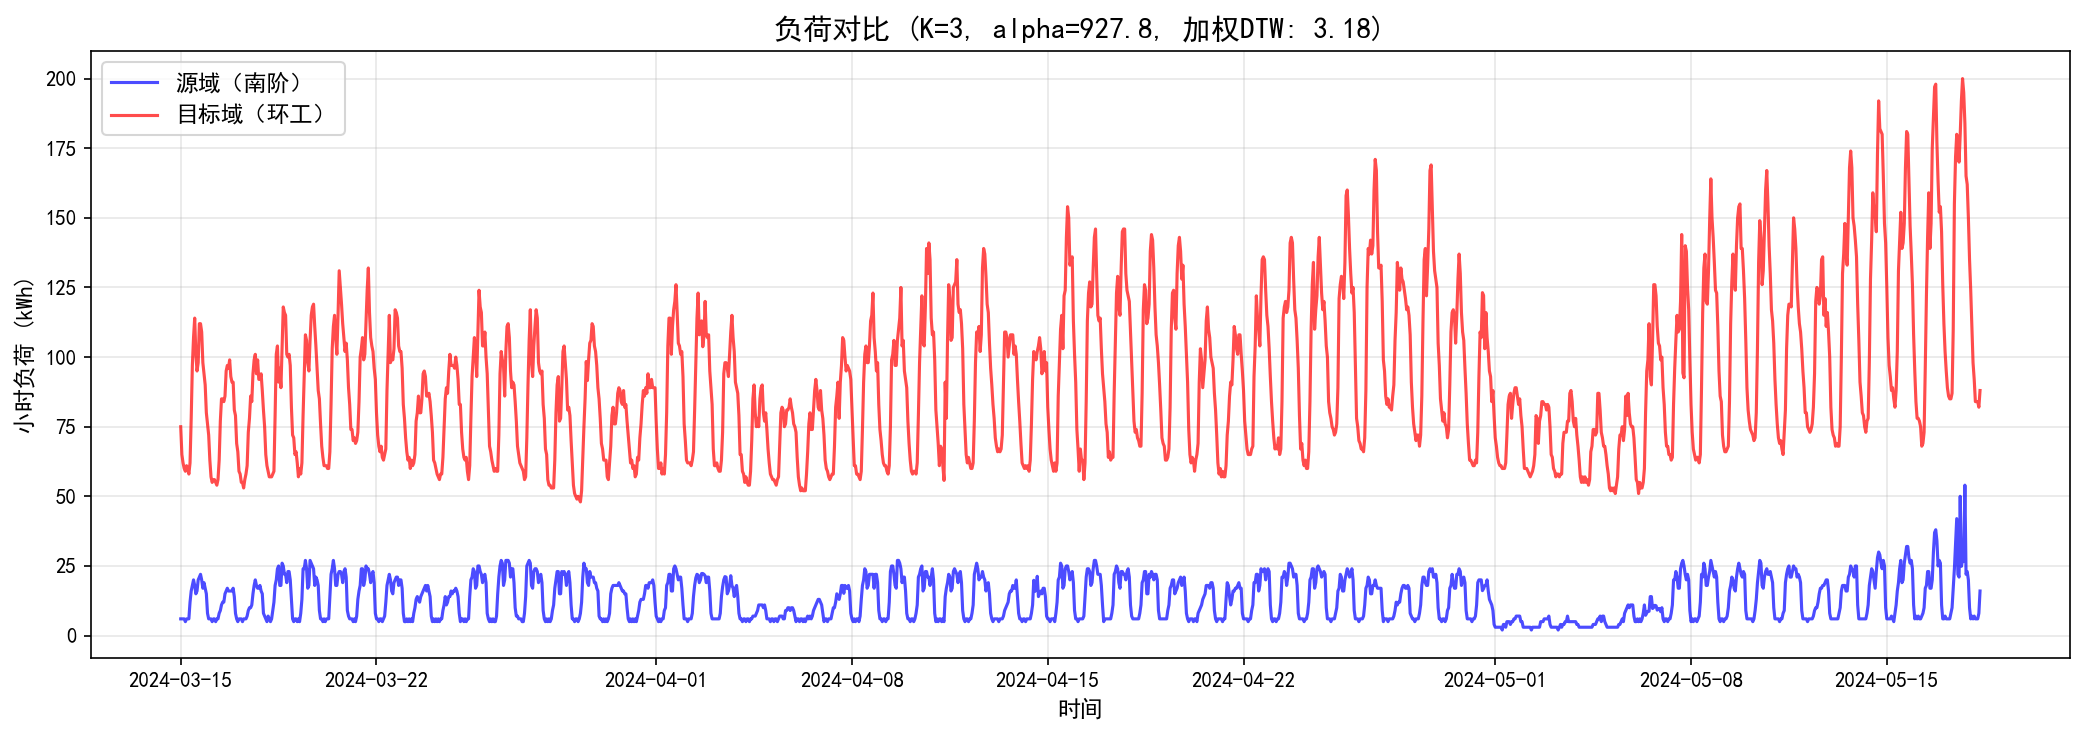

In [6]:
# 选择最佳建筑对进行详细可视化
result = best_result
common_idx = result['common_index']
K = result['K']
alpha = result['alpha']

source_name = result['source']
target_name = result['target']

# 根据源域/目标域确定对应的原始负荷
source_load = result['original_load_a'] if source_name == result['name_a'] else result['original_load_b']
target_load = result['original_load_b'] if target_name == result['name_b'] else result['original_load_a']

# 1. 原始负荷对比
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(common_idx, source_load.values, 'b-', alpha=0.7, label=f'源域（{source_name}）')
ax.plot(common_idx, target_load.values, 'r-', alpha=0.7, label=f'目标域（{target_name}）')
ax.set_title(f"负荷对比 (K={K}, alpha={alpha:.1f}, 加权DTW: {result['weighted_dtw']:.2f})", fontsize=14)
ax.set_xlabel('时间', fontsize=11)
ax.set_ylabel('小时负荷 (kWh)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '原始负荷对比.png', dpi=150, bbox_inches='tight')
plt.show()

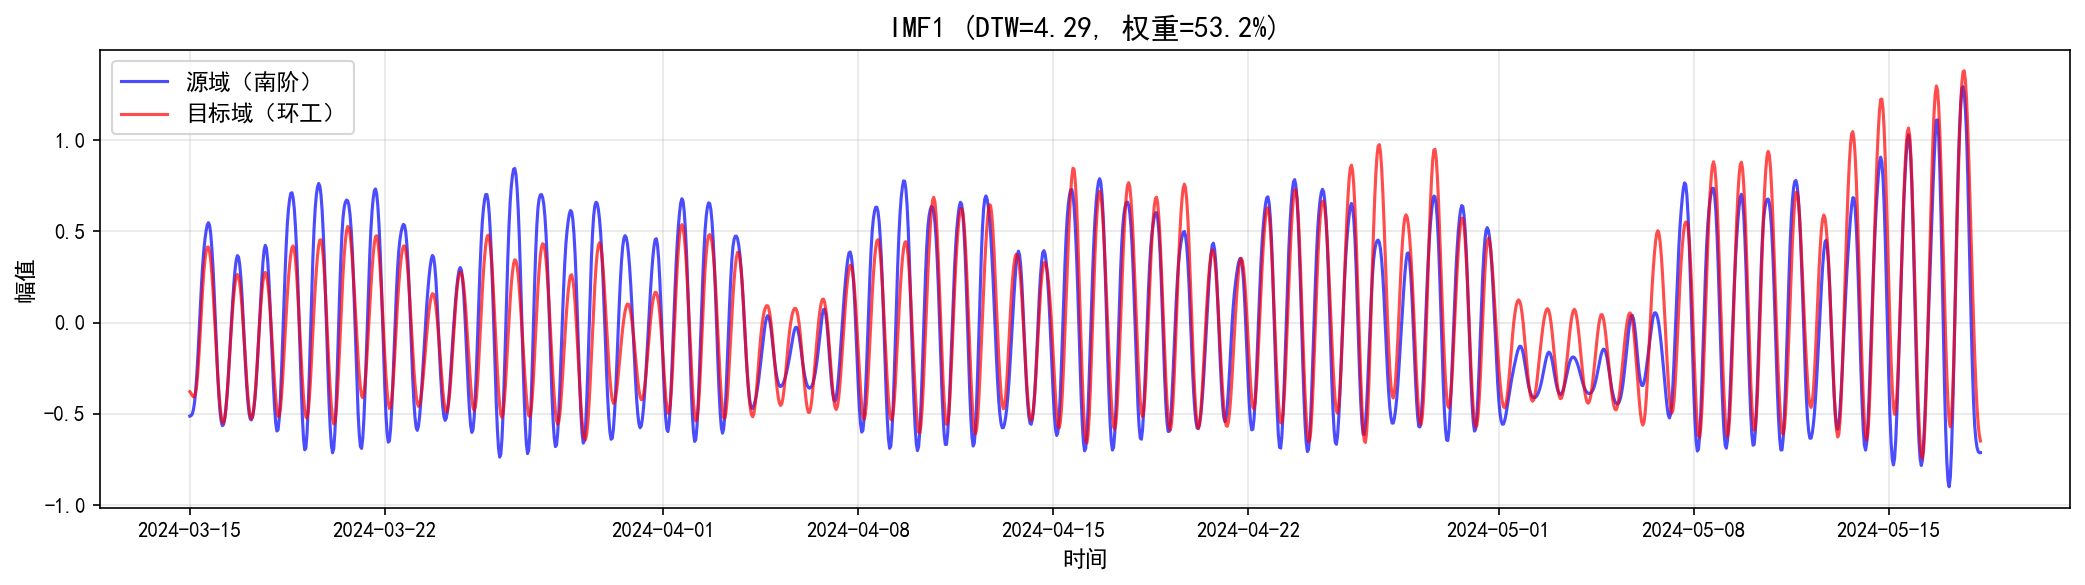

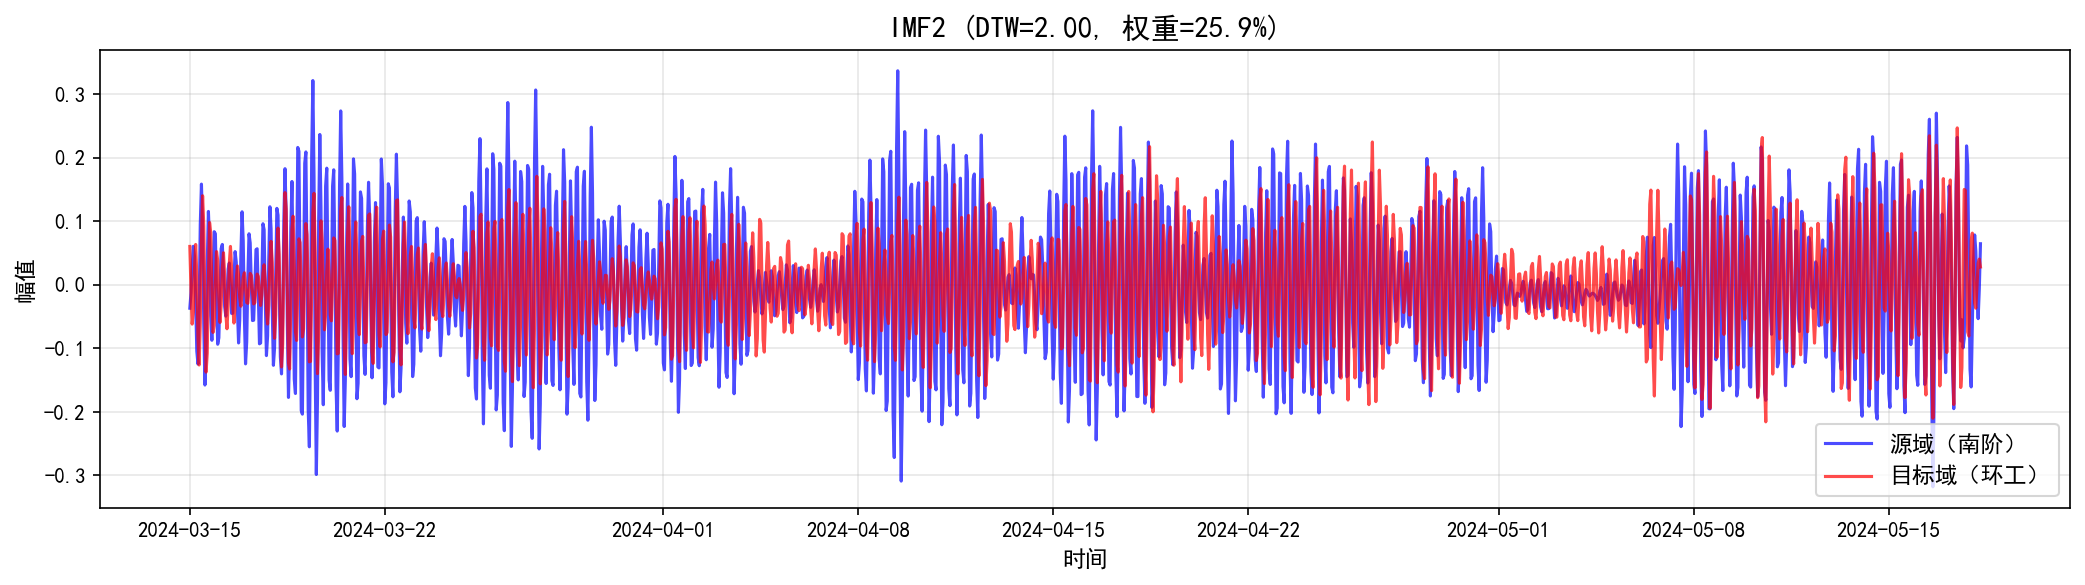

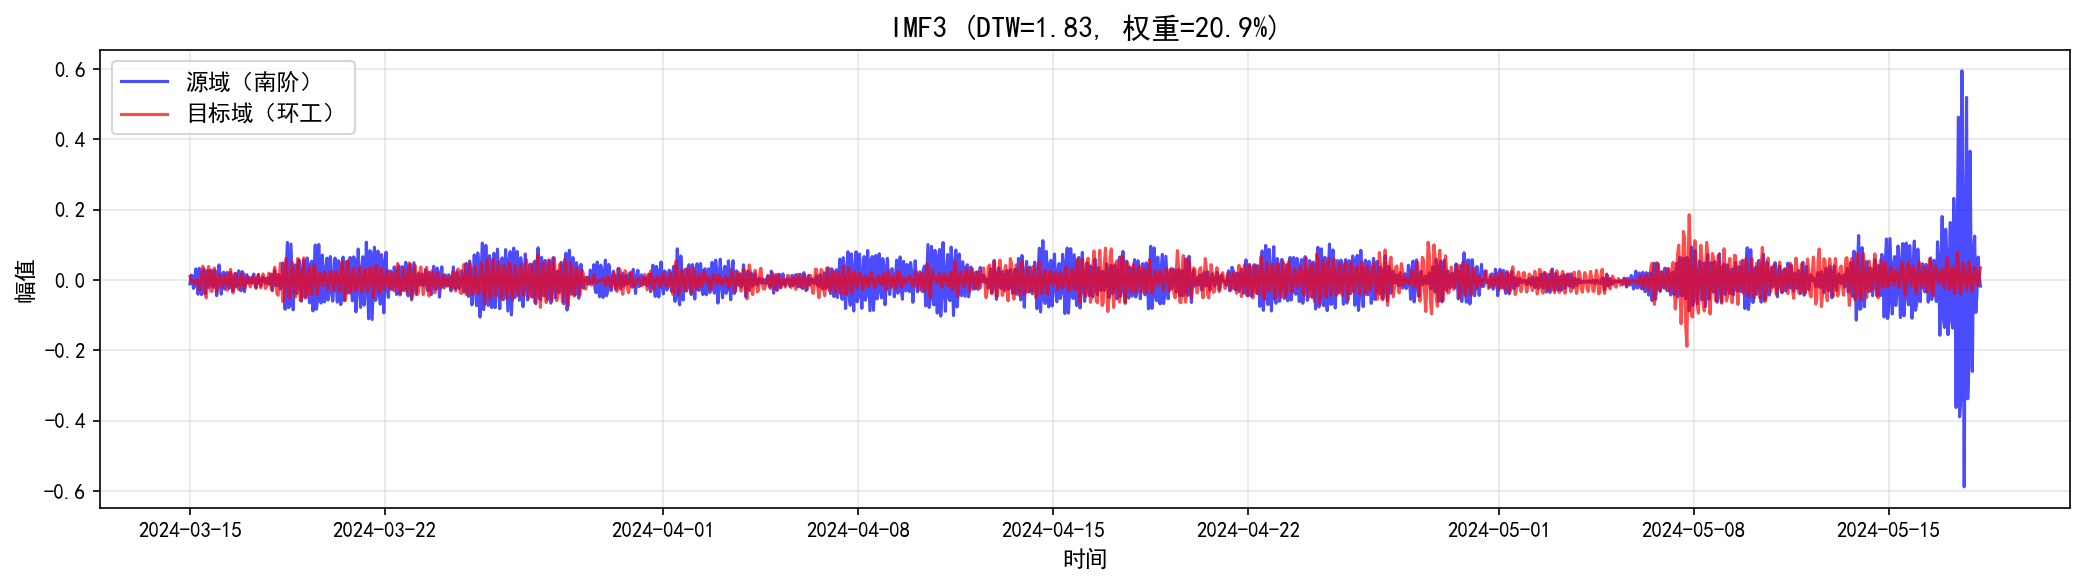

In [7]:
# 2. 各 IMF 分量对比
u_source = result['u_a'] if source_name == result['name_a'] else result['u_b']
u_target = result['u_b'] if target_name == result['name_b'] else result['u_a']

# 清理上次运行遗留的 IMF 分量对比图，避免 K 变小时旧图继续保留
for old_imf_plot in FIGURES_DIR.glob('IMF*对比.png'):
    imf_no = old_imf_plot.stem.removeprefix('IMF').removesuffix('对比')
    if imf_no.isdigit() and old_imf_plot.is_file():
        old_imf_plot.unlink()

for i in range(K):
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(common_idx[:u_source.shape[1]], u_source[i, :], 'b-', alpha=0.7, label=f'源域（{source_name}）')
    ax.plot(common_idx[:u_source.shape[1]], u_target[i, :], 'r-', alpha=0.7, label=f'目标域（{target_name}）')
    ax.set_title(f"IMF{i+1} (DTW={result['dtw_distances'][i]:.2f}, 权重={result['weights'][i]*100:.1f}%)", fontsize=14)
    ax.set_xlabel('时间', fontsize=11)
    ax.set_ylabel('幅值', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'IMF{i+1}对比.png', dpi=150, bbox_inches='tight')
    plt.show()

选择第 15 周作为典型周


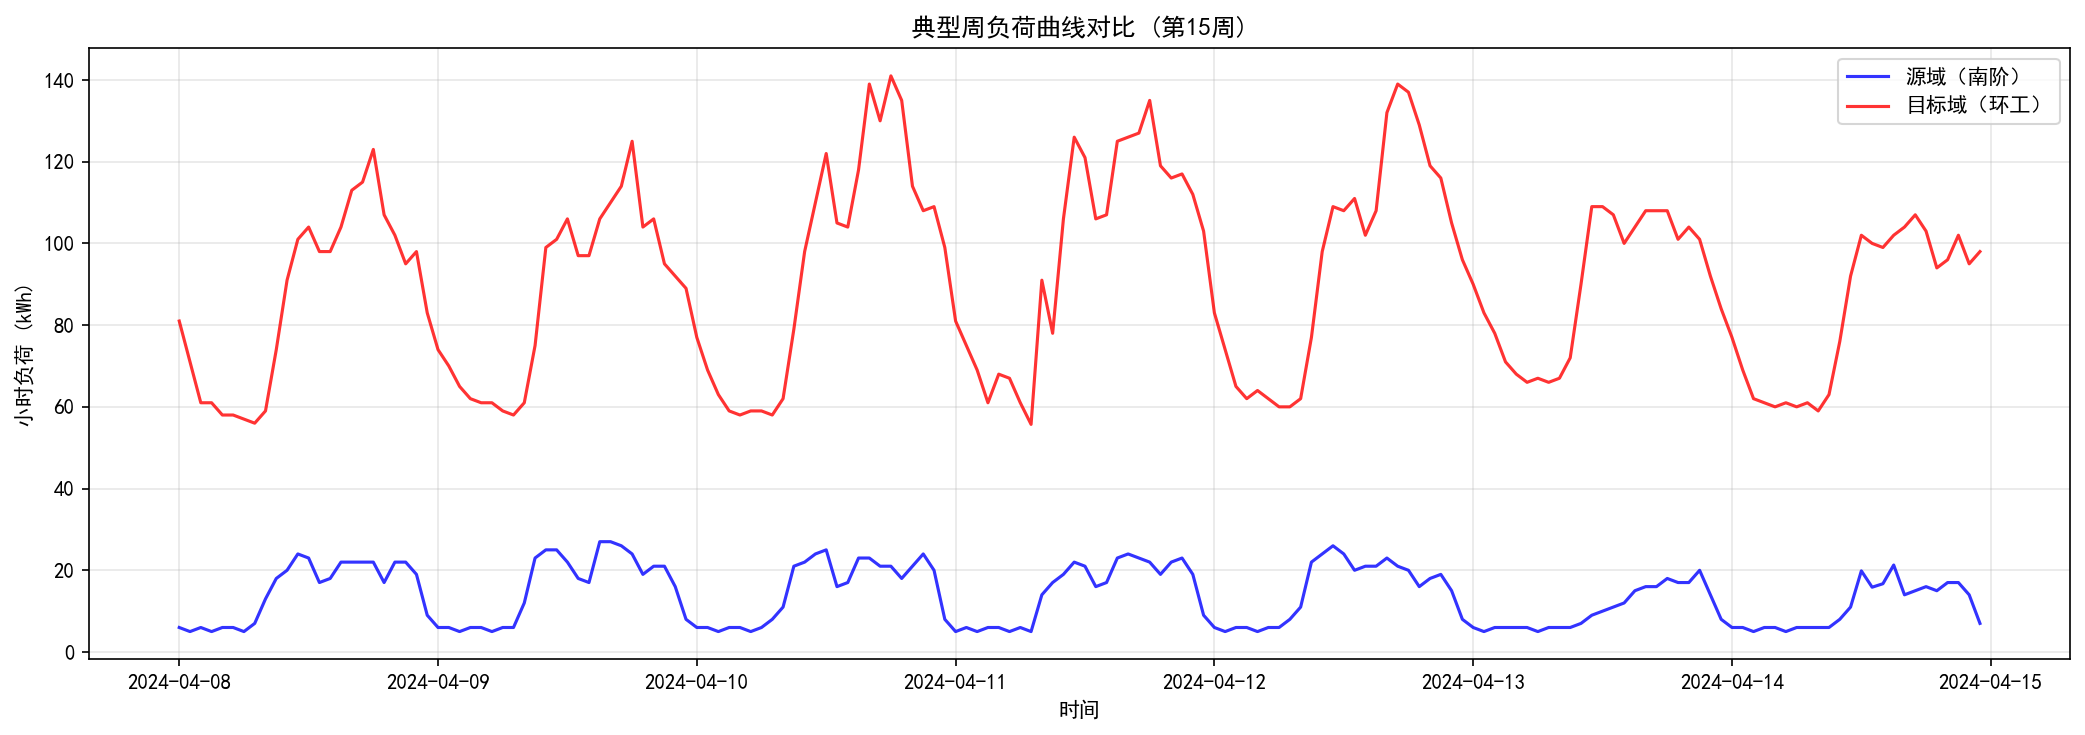

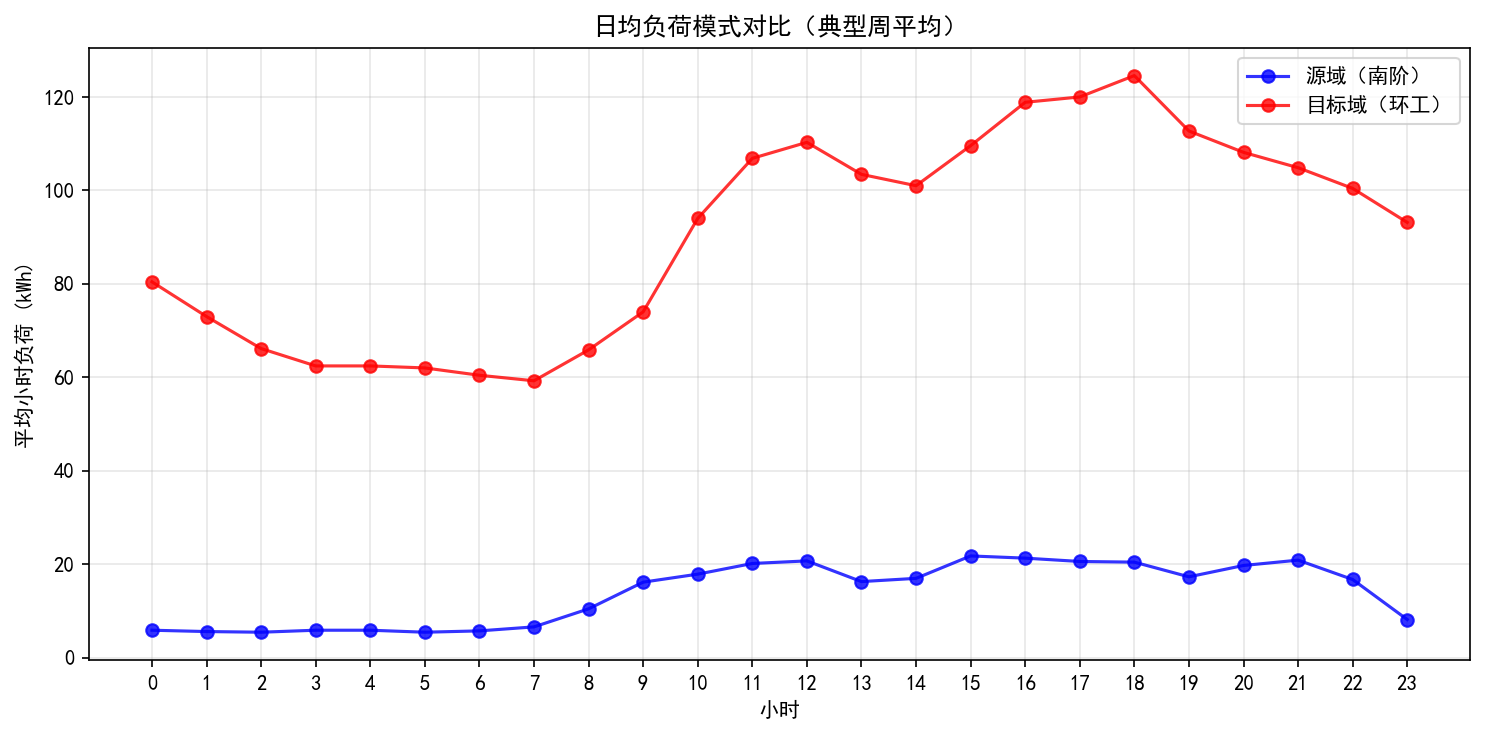

In [8]:
# 按周划分数据
df_weekly = pd.DataFrame({
    'source': source_load.loc[common_idx].values,
    'target': target_load.loc[common_idx].values,
}, index=common_idx)
df_weekly['week'] = df_weekly.index.isocalendar().week

# 选择周均负荷最接近整体均值的周作为典型周
weekly_stats = df_weekly.groupby('week').agg({'source': 'mean', 'target': 'mean'})
overall_mean_source = df_weekly['source'].mean()
overall_mean_target = df_weekly['target'].mean()

weekly_stats['total_diff'] = (
    abs(weekly_stats['source'] - overall_mean_source) +
    abs(weekly_stats['target'] - overall_mean_target)
)
typical_week = weekly_stats['total_diff'].idxmin()

print(f"选择第 {typical_week} 周作为典型周")

# 提取典型周数据
typical_week_idx = common_idx[common_idx.isocalendar().week == typical_week]

if len(typical_week_idx) >= 24:
    source_typical = source_load.loc[typical_week_idx]
    target_typical = target_load.loc[typical_week_idx]
    
    # 图1：典型周负荷曲线
    fig1, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(typical_week_idx, source_typical.values, 'b-', label=f'源域（{source_name}）', alpha=0.8)
    ax1.plot(typical_week_idx, target_typical.values, 'r-', label=f'目标域（{target_name}）', alpha=0.8)
    ax1.set_xlabel('时间')
    ax1.set_ylabel('小时负荷 (kWh)')
    ax1.set_title(f'典型周负荷曲线对比 (第{typical_week}周)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 图2：日均负荷模式
    source_daily = source_typical.groupby(source_typical.index.hour).mean()
    target_daily = target_typical.groupby(target_typical.index.hour).mean()
    
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.plot(range(24), source_daily.values, 'b-o', label=f'源域（{source_name}）', alpha=0.8)
    ax2.plot(range(24), target_daily.values, 'r-o', label=f'目标域（{target_name}）', alpha=0.8)
    ax2.set_xlabel('小时')
    ax2.set_ylabel('平均小时负荷 (kWh)')
    ax2.set_title('日均负荷模式对比（典型周平均）')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(range(24))
    plt.tight_layout()
    plt.show()

## 输出文件说明

**数据文件（`data/`）：**
| 文件 | 说明 |
|------|------|
| `相似性分析完整结果.json` | 完整分析结果（K值、alpha、经验熵适应度、DTW距离、权重） |
| `相似性分析汇总.csv` | 建筑对汇总表，包含联合优化后的 K、alpha、经验熵适应度与 VMD-DTW 结果 |
| `vmd_parameter_optimization.csv` | 各建筑对 VMD 参数优化摘要，包含经验熵适应度、迭代次数和函数评估次数 |

**图表文件（`data/figures/`）：**
| 文件 | 说明 |
|------|------|
| `原始负荷对比.png` | 源域与目标域负荷对比 |
| `IMF1对比.png` ~ `IMF{n}对比.png` | IMF 分量对比 |

### JSON 结构

```json
{
  "建筑A-建筑B": {
    "source": "源域建筑",
    "target": "目标域建筑",
    "K": "VMD分解层数",
    "alpha": "VMD惩罚因子",
    "entropy_fitness": "IMF经验熵加权总适应度",
    "source_entropy": "源域IMF经验熵加权和",
    "target_entropy": "目标域IMF经验熵加权和",
    "weighted_dtw": "加权DTW距离",
    "dtw_original": "原始序列DTW距离",
    "center_freq_source": ["源域各IMF中心频率"],
    "center_freq_target": ["目标域各IMF中心频率"],
    "imf_entropy_source": ["源域各IMF经验熵"],
    "imf_entropy_target": ["目标域各IMF经验熵"],
    "entropy_weights_source": ["源域各IMF经验熵权重"],
    "entropy_weights_target": ["目标域各IMF经验熵权重"],
    "dtw_distances": ["各IMF层DTW距离"],
    "weights": ["各IMF层DTW权重"]
  }
}
```


## 源域选择有效性的手动对比说明

如果需要在论文中验证“相似源域选择是否有效”，直观展示“高相似源域比低相似源域带来更明显迁移收益”，建议做轻量手动对比：

1. 从 `相似性分析汇总.csv` 中选取 `加权DTW` 最小的建筑对，作为“高相似源域”实验组合。
2. 从 `相似性分析汇总.csv` 中选取 `加权DTW` 最大的建筑对，作为“低相似源域”实验组合。
3. 手动修改 `src/config.py` 中的 `SOURCE_BUILDING` 和 `TARGET_BUILDING`，分别运行 `prepare_transfer_data.ipynb` 与 `transfer_learning.ipynb` 获取两组结果。
4. 记录每组的 `baseline_MAE` 和论文主迁移策略的 `transfer_MAE`，计算迁移收益：

```
PIR = (baseline_MAE - transfer_MAE) / baseline_MAE * 100
```